
 QUANTUM NOISE ANALYSIS AND CONTROL
 Implementation of Stochastic Differential Equation Approach

[Running Example 1: Qubit System]

EXAMPLE 1: QUBIT SYSTEM WITH PAULI NOISE
Initialized QuantumNoiseEstimator:
 - System dimension: 2
 - Number of noise parameters: 3
 - Perturbation strength ε: 0.05
 - Hamiltonian eigenvalues: [-1.  1.]

QUANTUM PARAMETER ESTIMATION ALGORITHM

Processing Observable 1/3...
 Time-averaged scaled deviation: 0.041608

Processing Observable 2/3...
 Time-averaged scaled deviation: -0.032719

Processing Observable 3/3...
 Time-averaged scaled deviation: 1.360000

----------------------------------------------------------------------
Parameter Estimation via Quadratic Fitting
----------------------------------------------------------------------

True parameters: [0.3 0.5 0.2]
Estimated parameters: [0. 0. 0.]
Estimation error: 0.616441

[Running Example 2: Time Evolution]

EXAMPLE 2: TIME EVOLUTION VISUALIZATION
Initialized QuantumNoiseEstimator:
 - System dimen

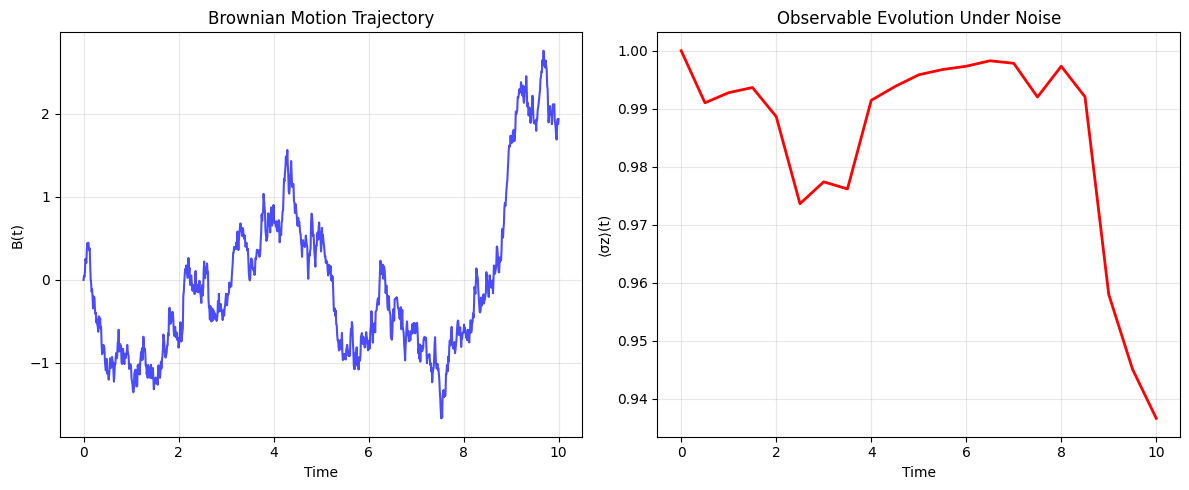

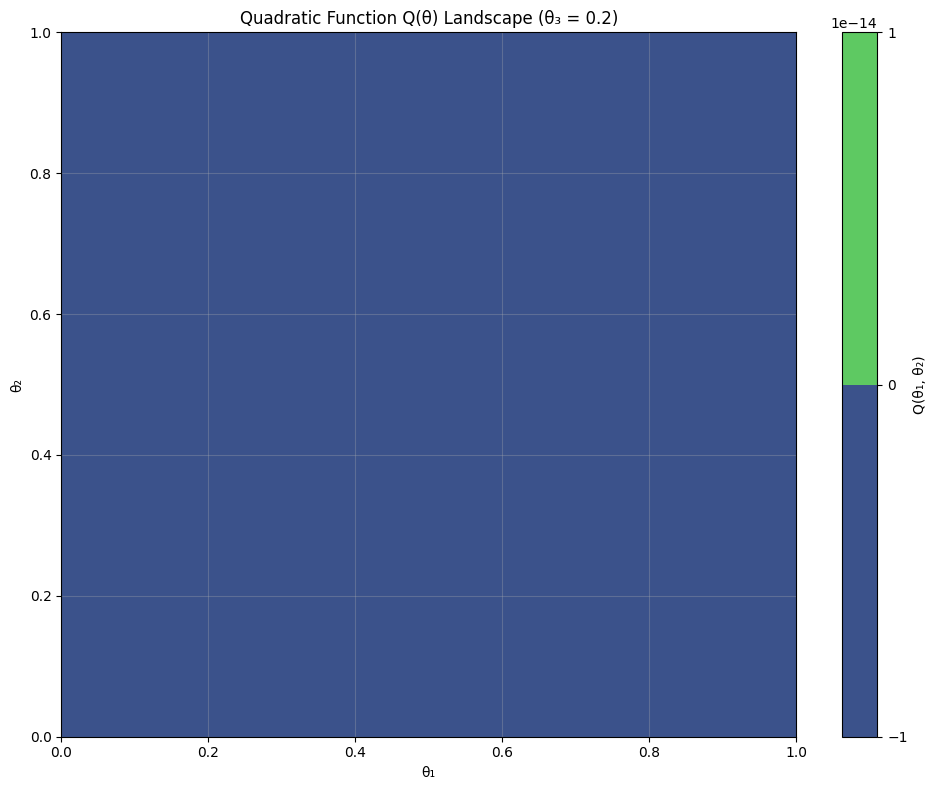

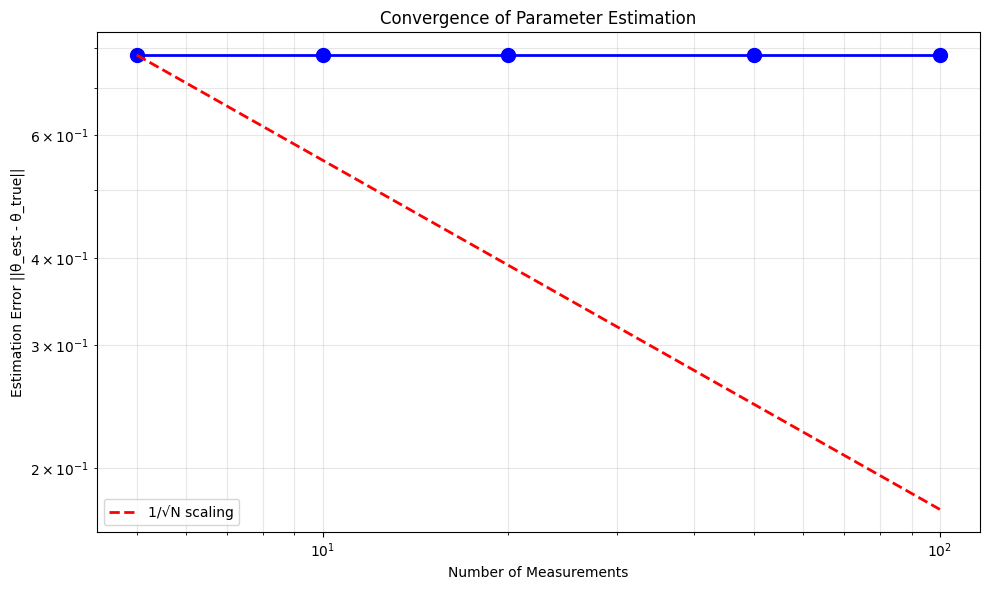

In [ ]:
"""
Stochastic Differential Equations Approaches to Quantum System Noise Analysis and Control
Implementation of Algorithm 1 from the paper
This module implements quantum parameter estimation under classical noise using
Ito stochastic calculus and perturbation theory.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import simpson
from typing import List, Tuple, Optional, Dict
import warnings
warnings.filterwarnings('ignore')
# Qiskit imports for quantum operations
try:
    from qiskit.quantum_info import Operator, DensityMatrix
    from qiskit import QuantumCircuit
    QISKIT_AVAILABLE = True
except ImportError:
    print("Warning: Qiskit not available. Using NumPy-only implementation.")
    QISKIT_AVAILABLE = False

class QuantumNoiseEstimator:
    """
    Main class for quantum parameter estimation under stochastic noise.
    Implements the perturbative expansion of the unitary evolution operator
    up to O(ε²) for a quantum system subjected to white Gaussian noise.
    """

    def __init__(self, hamiltonian: np.ndarray, noise_operators: List[np.ndarray], epsilon: float = 0.1, dim: int = 2):
        """
        Initialize the quantum noise estimator.
        Parameters:
        -----------
        hamiltonian : np.ndarray
            The unperturbed Hamiltonian H of the quantum system
        noise_operators : List[np.ndarray]
            List of Hermitian operators Vk that modulate the noise
        epsilon : float
            Perturbation parameter (should be small)
        dim : int
            Dimension of the Hilbert space
        """
        self.H = hamiltonian
        self.Vk_list = noise_operators
        self.epsilon = epsilon
        self.dim = dim
        self.p = len(noise_operators)  # Number of noise parameters

        # Validate inputs
        self._validate_inputs()

        # Compute eigensystem of Hamiltonian
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.H)
        self.eigenprojections = self._compute_eigenprojections()

        print(f"Initialized QuantumNoiseEstimator:")
        print(f" - System dimension: {self.dim}")
        print(f" - Number of noise parameters: {self.p}")
        print(f" - Perturbation strength ε: {self.epsilon}")
        print(f" - Hamiltonian eigenvalues: {self.eigenvalues}")

    def _validate_inputs(self):
        """Validate that inputs are properly formatted."""
        assert self.H.shape == (self.dim, self.dim), "Hamiltonian must be square"
        assert np.allclose(self.H, self.H.conj().T), "Hamiltonian must be Hermitian"
        for i, Vk in enumerate(self.Vk_list):
            assert Vk.shape == (self.dim, self.dim), f"Noise operator {i} must be square"
            assert np.allclose(Vk, Vk.conj().T), f"Noise operator {i} must be Hermitian"

    def _compute_eigenprojections(self) -> List[np.ndarray]:
        """
        Compute eigenprojections Pα = |α⟩⟨α| for each eigenstate of H.
        Returns:
        --------
        List of projection operators
        """
        projections = []
        for i in range(self.dim):
            v = self.eigenvectors[:, i].reshape(-1, 1)
            P = v @ v.conj().T
            projections.append(P)
        return projections

    def generate_brownian_motion(self,
                                 t_final: float,
                                 n_steps: int,
                                 n_realizations: int = 1) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate Brownian motion trajectories.
        Parameters:
        -----------
        t_final : float
            Final time
        n_steps : int
            Number of time steps
        n_realizations : int
            Number of independent Brownian motion realizations
        Returns:
        --------
        times : np.ndarray
            Time array
        brownian_paths : np.ndarray
            Brownian motion trajectories, shape (n_realizations, n_steps+1)
        """
        dt = t_final / n_steps
        times = np.linspace(0, t_final, n_steps + 1)
        # Generate increments dB(t) ~ N(0, dt)
        dB = np.random.normal(0, np.sqrt(dt), (n_realizations, n_steps))
        # Cumulative sum to get B(t)
        brownian_paths = np.zeros((n_realizations, n_steps + 1))
        brownian_paths[:, 1:] = np.cumsum(dB, axis=1)
        return times, brownian_paths

    def U0(self, t: float) -> np.ndarray:
        """
        Compute U₀(t) = exp(-itH), the zeroth-order evolution operator.
        Parameters:
        -----------
        t : float
            Time
        Returns:
        --------
        U₀(t) : np.ndarray
            Unperturbed unitary evolution operator
        """
        return expm(-1j * t * self.H)

    def compute_V(self, theta: np.ndarray) -> np.ndarray:
        """
        Compute V = Σ θk Vk, the noise modulating potential.
        Parameters:
        -----------
        theta : np.ndarray
            Array of noise parameters θk
        Returns:
        --------
        V : np.ndarray
            Combined noise operator
        """
        assert len(theta) == self.p, f"Need {self.p} parameters, got {len(theta)}"
        V = np.zeros((self.dim, self.dim), dtype=complex)
        for k in range(self.p):
            V += theta[k] * self.Vk_list[k]
        return V

    def compute_U1(self,
                   t: float,
                   theta: np.ndarray,
                   brownian_times: np.ndarray,
                   brownian_path: np.ndarray) -> np.ndarray:
        """
        Compute first-order term U₁(t) using Ito stochastic integral.
        From Eq. (12): U₁(t) = -i ∫₀ᵗ U₀(t-τ) V U₀(τ) dB(τ)
        Parameters:
        -----------
        t : float
            Final time
        theta : np.ndarray
            Noise parameters
        brownian_times : np.ndarray
            Time points for Brownian motion
        brownian_path : np.ndarray
            Brownian motion trajectory
        Returns:
        --------
        U₁(t) : np.ndarray
            First-order correction to evolution operator
        """
        V = self.compute_V(theta)
        # Find index corresponding to time t
        idx = np.argmin(np.abs(brownian_times - t))
        n_steps = idx
        U1 = np.zeros((self.dim, self.dim), dtype=complex)
        # Ito integral using discrete approximation
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dB = brownian_path[i] - brownian_path[i-1]
            integrand = self.U0(t - tau) @ V @ self.U0(tau)
            U1 += -1j * integrand * dB
        return U1

    def compute_U2(self,
                   t: float,
                   theta: np.ndarray,
                   brownian_times: np.ndarray,
                   brownian_path: np.ndarray,
                   U1: Optional[np.ndarray] = None) -> np.ndarray:
        """
        Compute second-order term U₂(t) using double Ito integral.
        From Eq. (13):
        U₂(t) = -i ∫₀ᵗ U₀(t-τ) V U₁(τ) dB(τ) - (1/2) ∫₀ᵗ U₀(t-τ) V² U₀(τ) dτ
        Parameters:
        -----------
        t : float
            Final time
        theta : np.ndarray
            Noise parameters
        brownian_times : np.ndarray
            Time points
        brownian_path : np.ndarray
            Brownian motion trajectory
        U1 : np.ndarray, optional
            Pre-computed U₁, if available
        Returns:
        --------
        U₂(t) : np.ndarray
            Second-order correction to evolution operator
        """
        V = self.compute_V(theta)
        V2 = V @ V
        # Find index corresponding to time t
        idx = np.argmin(np.abs(brownian_times - t))
        n_steps = idx
        U2 = np.zeros((self.dim, self.dim), dtype=complex)
        # First term: -i ∫₀ᵗ U₀(t-τ) V U₁(τ) dB(τ)
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dB = brownian_path[i] - brownian_path[i-1]
            # Need to compute U₁(τ) for each τ
            U1_tau = self.compute_U1(tau, theta, brownian_times, brownian_path)
            integrand = self.U0(t - tau) @ V @ U1_tau
            U2 += -1j * integrand * dB
        # Second term: -(1/2) ∫₀ᵗ U₀(t-τ) V² U₀(τ) dτ
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dtau = brownian_times[i] - brownian_times[i-1]
            integrand = self.U0(t - tau) @ V2 @ self.U0(tau)
            U2 += -0.5 * integrand * dtau
        return U2

    def compute_U_perturbative(self,
                               t: float,
                               theta: np.ndarray,
                               brownian_times: np.ndarray,
                               brownian_path: np.ndarray,
                               order: int = 2) -> np.ndarray:
        """
        Compute full perturbative expansion of U(t) up to order ε².
        U(t) = U₀(t) + ε U₁(t) + ε² U₂(t) + O(ε³)
        Parameters:
        -----------
        t : float
            Time
        theta : np.ndarray
            Noise parameters
        brownian_times : np.ndarray
            Time points
        brownian_path : np.ndarray
            Brownian motion trajectory
        order : int
            Maximum perturbation order (1 or 2)
        Returns:
        --------
        U(t) : np.ndarray
            Unitary evolution operator
        """
        U = self.U0(t)
        if order >= 1:
            U1 = self.compute_U1(t, theta, brownian_times, brownian_path)
            U += self.epsilon * U1
        if order >= 2:
            U2 = self.compute_U2(t, theta, brownian_times, brownian_path)
            U += self.epsilon**2 * U2
        return U

    def compute_observable_evolution(self,
                                     X: np.ndarray,
                                     t: float,
                                     theta: np.ndarray,
                                     brownian_times: np.ndarray,
                                     brownian_path: np.ndarray) -> np.ndarray:
        """
        Compute X(t) = U†(t) X U(t), the evolved observable.
        Parameters:
        -----------
        X : np.ndarray
            Observable operator
        t : float
            Time
        theta : np.ndarray
            Noise parameters
        brownian_times : np.ndarray
            Time points
        brownian_path : np.ndarray
            Brownian motion trajectory
        Returns:
        --------
        X(t) : np.ndarray
            Evolved observable
        """
        U = self.compute_U_perturbative(t, theta, brownian_times, brownian_path)
        return U.conj().T @ X @ U

    def compute_expectation_value(self,
                                  X: np.ndarray,
                                  rho0: np.ndarray,
                                  t: float,
                                  theta: np.ndarray,
                                  n_steps: int = 1000) -> float:
        """
        Compute ensemble-averaged expectation value E[⟨X(t)⟩].
        ⟨X⟩(t) = Tr[U(t) ρ(0) U†(t) X] = Tr[ρ(0) U†(t) X U(t)]
        Uses deterministic second-order terms from Eq. (18-19).
        Parameters:
        -----------
        X : np.ndarray
            Observable
        rho0 : np.ndarray
            Initial density matrix
        t : float
            Time
        theta : np.ndarray
            Noise parameters
        n_steps : int
            Number of time steps for integration
        Returns:
        --------
        expectation : float
            Ensemble-averaged expectation value
        """
        V = self.compute_V(theta)
        V2 = V @ V
        U0 = self.U0(t)
        U0_dag = U0.conj().T
        X0 = U0_dag @ X @ U0
        exp0 = np.trace(rho0 @ X0).real
        # Second order terms
        dt = t / n_steps
        term1 = 0.0
        term2 = 0.0
        term3 = 0.0
        for i in range(n_steps):
            tau = (i + 0.5) * dt  # Midpoint rule
            U0_tau = self.U0(tau)
            U0_dag_tau = U0_tau.conj().T
            U0_t_tau = self.U0(t - tau)
            U0_dag_t_tau = U0_t_tau.conj().T
            int1 = U0_dag @ X @ U0_t_tau @ V2 @ U0_tau
            term1 += -0.5 * np.trace(rho0 @ int1).real * dt
            int2 = U0_dag_tau @ V2 @ U0_dag_t_tau @ X @ U0
            term2 += -0.5 * np.trace(rho0 @ int2).real * dt
            int3 = U0_dag_tau @ V @ U0_dag_t_tau @ X @ U0_t_tau @ V @ U0_tau
            term3 += np.trace(rho0 @ int3).real * dt
        exp2 = term1 + term2 + term3
        return exp0 + self.epsilon**2 * exp2

    def compute_Q_function(self,
                           X: np.ndarray,
                           rho0: np.ndarray,
                           theta: np.ndarray) -> float:
        """
        Compute the quadratic function Q(θ) for parameter estimation.
        From Eq. (25), including trace with ρ(0):
        Q = Σ θk θm Tr(ρ(0) [PαXPαVkVmPα + PαVkVmPαXPα
                     - PαVkPαXPαVmPα - PαVkPβXPβVmPα])
        Parameters:
        -----------
        X : np.ndarray
            Observable
        rho0 : np.ndarray
            Initial density matrix
        theta : np.ndarray
            Noise parameters
        Returns:
        --------
        Q : float
            Value of quadratic function
        """
        Q_matrix = np.zeros((self.p, self.p))
        for k in range(self.p):
            for m in range(self.p):
                Vk = self.Vk_list[k]
                Vm = self.Vk_list[m]
                Q_km = 0
                for alpha in range(self.dim):
                    Pa = self.eigenprojections[alpha]
                    # Term 1: PαXPαVkVmPα
                    term1 = Pa @ X @ Pa @ Vk @ Vm @ Pa
                    # Term 2: PαVkVmPαXPα
                    term2 = Pa @ Vk @ Vm @ Pa @ X @ Pa
                    # Term 3: -PαVkPαXPαVmPα
                    term3 = -Pa @ Vk @ Pa @ X @ Pa @ Vm @ Pa
                    # Term 4: -PαVkPβXPβVmPα (summed over β)
                    term4 = np.zeros((self.dim, self.dim), dtype=complex)
                    for beta in range(self.dim):
                        Pb = self.eigenprojections[beta]
                        term4 += -Pa @ Vk @ Pb @ X @ Pb @ Vm @ Pa
                    Q_km += np.trace(rho0 @ (term1 + term2 + term3 + term4)).real
                Q_matrix[k, m] = Q_km
        # Compute θᵀ Q θ
        Q_value = theta @ Q_matrix @ theta
        return Q_value

    def estimate_parameters(self,
                            X_observables: List[np.ndarray],
                            rho0: np.ndarray,
                            true_theta: np.ndarray,
                            t_final: float = 10.0,
                            n_measurements: int = 50,
                            n_steps: int = 1000) -> np.ndarray:
        """
        Estimate noise parameters θk from time-averaged measurements.
        This is the main algorithm implementation.
        Parameters:
        -----------
        X_observables : List[np.ndarray]
            List of observables to measure
        rho0 : np.ndarray
            Initial state
        true_theta : np.ndarray
            True parameters (for generating data)
        t_final : float
            Final time for measurements
        n_measurements : int
            Number of time points to measure
        n_steps : int
            Number of time steps per integration
        Returns:
        --------
        theta_estimated : np.ndarray
            Estimated parameters
        """
        print("\n" + "="*70)
        print("QUANTUM PARAMETER ESTIMATION ALGORITHM")
        print("="*70)
        # Step 1: Generate measurement times (large times to approximate limit)
        times = np.linspace(t_final / 2, t_final, n_measurements)
        # Step 2: Compute time-averaged scaled deviations for each X
        Q_measurements = []
        for idx, X in enumerate(X_observables):
            print(f"\nProcessing Observable {idx+1}/{len(X_observables)}...")
            scaled_values = []
            for t in times:
                exp_val = self.compute_expectation_value(
                    X, rho0, t, true_theta, n_steps
                )
                # Compute unperturbed
                U0 = self.U0(t)
                U0_dag = U0.conj().T
                X0 = U0_dag @ X @ U0
                exp_val0 = np.trace(rho0 @ X0).real
                # Scaled deviation
                scaled = -2 / (self.epsilon**2 * t) * (exp_val - exp_val0)
                scaled_values.append(scaled)
            # Compute time average
            Q_measurement = np.mean(scaled_values)
            Q_measurements.append(Q_measurement)
            print(f" Time-averaged scaled deviation: {Q_measurement:.6f}")
        # Step 3: Set up optimization problem
        print("\n" + "-"*70)
        print("Parameter Estimation via Quadratic Fitting")
        print("-"*70)
        # For demonstration, we'll use a simple grid search or least squares
        # In practice, more sophisticated methods should be used
        theta_estimated = self._estimate_via_least_squares(
            X_observables, rho0, Q_measurements
        )
        print(f"\nTrue parameters: {true_theta}")
        print(f"Estimated parameters: {theta_estimated}")
        print(f"Estimation error: {np.linalg.norm(theta_estimated - true_theta):.6f}")
        return theta_estimated

    def _estimate_via_least_squares(self,
                                    X_observables: List[np.ndarray],
                                    rho0: np.ndarray,
                                    Q_measurements: List[float]) -> np.ndarray:
        """
        Estimate parameters using least squares optimization.
        This is a simplified approach. More sophisticated methods
        should be used in practice.
        """
        from scipy.optimize import minimize
        def objective(theta):
            error = 0
            for X, Q_meas in zip(X_observables, Q_measurements):
                Q_pred = self.compute_Q_function(X, rho0, theta)
                error += (Q_pred - Q_meas)**2
            return error
        initial_guess = np.zeros(self.p)
        result = minimize(objective, initial_guess, method='BFGS')
        return result.x

class QuantumNoiseSimulator:
    """
    Simulator for demonstrating the algorithm with specific examples.
    """

    @staticmethod
    def create_pauli_system(epsilon: float = 0.1) -> QuantumNoiseEstimator:
        """
        Create a simple qubit system with Pauli operators.
        Returns:
        --------
        estimator : QuantumNoiseEstimator
            Initialized estimator for a qubit
        """
        # Pauli matrices
        sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
        sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
        sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
        # Hamiltonian: H = ω σz
        omega = 1.0
        H = omega * sigma_z
        # Noise operators: Vk = {σx, σy, σz}
        noise_operators = [sigma_x, sigma_y, sigma_z]
        return QuantumNoiseEstimator(H, noise_operators, epsilon, dim=2)

    @staticmethod
    def create_harmonic_oscillator(n_levels: int = 4,
                                   epsilon: float = 0.1) -> QuantumNoiseEstimator:
        """
        Create a truncated harmonic oscillator system.
        Parameters:
        -----------
        n_levels : int
            Number of Fock states to include
        epsilon : float
            Perturbation parameter
        Returns:
        --------
        estimator : QuantumNoiseEstimator
            Initialized estimator for harmonic oscillator
        """
        # Creation and annihilation operators
        a = np.diag(np.sqrt(np.arange(1, n_levels)), 1)
        a_dag = a.T
        # Number operator
        n_op = a_dag @ a
        # Hamiltonian: H = ω(n + 1/2)
        omega = 1.0
        H = omega * (n_op + 0.5 * np.eye(n_levels))
        # Position and momentum operators
        x_op = (a + a_dag) / np.sqrt(2)
        p_op = -1j * (a - a_dag) / np.sqrt(2)
        # Noise operators
        noise_operators = [x_op, p_op, n_op]
        return QuantumNoiseEstimator(H, noise_operators, epsilon, dim=n_levels)

def example_qubit_system():
    """
    Example: Estimate noise parameters for a qubit system.
    """
    print("\n" + "="*70)
    print("EXAMPLE 1: QUBIT SYSTEM WITH PAULI NOISE")
    print("="*70)
    # Create system
    epsilon = 0.05
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon)
    # True parameters (unknown in practice)
    true_theta = np.array([0.3, 0.5, 0.2])
    # Initial state: |0⟩
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    # Observables to measure
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    X_observables = [sigma_x, sigma_y, sigma_z]
    # Estimate parameters
    theta_est = estimator.estimate_parameters(
        X_observables,
        rho0,
        true_theta,
        t_final=5.0,
        n_measurements=20,
        n_steps=500
    )
    return estimator, true_theta, theta_est

def example_time_evolution():
    """
    Example: Visualize unitary evolution under noise.
    """
    print("\n" + "="*70)
    print("EXAMPLE 2: TIME EVOLUTION VISUALIZATION")
    print("="*70)
    # Create system
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.1)
    # Parameters
    theta = np.array([0.5, 0.3, 0.2])
    # Generate single Brownian path
    t_final = 10.0
    n_steps = 1000
    times, brownian_paths = estimator.generate_brownian_motion(
        t_final, n_steps, n_realizations=1
    )
    brownian_path = brownian_paths[0]
    # Observable
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    # Initial state
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    # Compute evolution
    print("\nComputing time evolution...")
    expectation_values = []
    time_points = times[::50]  # Sample every 50 points
    for t in time_points:
        U = estimator.compute_U_perturbative(t, theta, times, brownian_path, order=2)
        X_evolved = U.conj().T @ sigma_z @ U
        exp_val = np.trace(rho0 @ X_evolved).real
        expectation_values.append(exp_val)
    # Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(times, brownian_path, 'b-', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('B(t)')
    plt.title('Brownian Motion Trajectory')
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(time_points, expectation_values, 'r-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('⟨σz⟩(t)')
    plt.title('Observable Evolution Under Noise')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('time_evolution.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'time_evolution.png'")
    return times, expectation_values

def example_parameter_scan():
    """
    Example: Scan parameter space and visualize Q function.
    """
    print("\n" + "="*70)
    print("EXAMPLE 3: PARAMETER SPACE SCAN")
    print("="*70)
    # Create system
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.1)
    # Initial state for Q
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    # Observable
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    # Scan 2D parameter space (fixing θ3 = 0.2)
    theta3_fixed = 0.2
    theta1_range = np.linspace(0, 1, 30)
    theta2_range = np.linspace(0, 1, 30)
    Q_values = np.zeros((len(theta1_range), len(theta2_range)))
    print("\nScanning parameter space...")
    for i, theta1 in enumerate(theta1_range):
        for j, theta2 in enumerate(theta2_range):
            theta = np.array([theta1, theta2, theta3_fixed])
            Q_values[i, j] = estimator.compute_Q_function(sigma_x, rho0, theta)
    # Plot
    plt.figure(figsize=(10, 8))
    T1, T2 = np.meshgrid(theta1_range, theta2_range)
    plt.contourf(T1, T2, Q_values.T, levels=20, cmap='viridis')
    plt.colorbar(label='Q(θ₁, θ₂)')
    plt.xlabel('θ₁')
    plt.ylabel('θ₂')
    plt.title(f'Quadratic Function Q(θ) Landscape (θ₃ = {theta3_fixed})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('parameter_scan.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'parameter_scan.png'")
    return Q_values

def example_convergence_analysis():
    """
    Example: Analyze convergence with increasing measurements.
    """
    print("\n" + "="*70)
    print("EXAMPLE 4: CONVERGENCE ANALYSIS")
    print("="*70)
    # Create system
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.05)
    # True parameters
    true_theta = np.array([0.4, 0.6, 0.3])
    # Initial state and observables
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    X_observables = [sigma_x, sigma_y, sigma_z]
    # Test different numbers of measurements
    n_measurement_values = [5, 10, 20, 50, 100]
    errors = []
    print("\nTesting convergence with increasing measurements...")
    for n_meas in n_measurement_values:
        print(f"\n Testing with {n_meas} measurements...")
        theta_est = estimator.estimate_parameters(
            X_observables,
            rho0,
            true_theta,
            t_final=5.0,
            n_measurements=n_meas,
            n_steps=300
        )
        error = np.linalg.norm(theta_est - true_theta)
        errors.append(error)
    # Plot convergence
    plt.figure(figsize=(10, 6))
    plt.loglog(n_measurement_values, errors, 'bo-', markersize=10, linewidth=2)
    plt.xlabel('Number of Measurements')
    plt.ylabel('Estimation Error ||θ_est - θ_true||')
    plt.title('Convergence of Parameter Estimation')
    plt.grid(True, alpha=0.3, which='both')
    # Add theoretical scaling
    theoretical = errors[0] * (np.array(n_measurement_values) / n_measurement_values[0])**(-0.5)
    plt.loglog(n_measurement_values, theoretical, 'r--',
               linewidth=2, label='1/√N scaling')
    plt.legend()
    plt.tight_layout()
    plt.savefig('convergence_analysis.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'convergence_analysis.png'")
    return n_measurement_values, errors

def main():
    """
    Main function to run all examples.
    """
    print("\n" + "="*70)
    print(" QUANTUM NOISE ANALYSIS AND CONTROL")
    print(" Implementation of Stochastic Differential Equation Approach")
    print("="*70)
    # Set random seed for reproducibility
    np.random.seed(42)
    # Run examples
    print("\n[Running Example 1: Qubit System]")
    estimator1, true_theta1, est_theta1 = example_qubit_system()
    print("\n[Running Example 2: Time Evolution]")
    times, expectations = example_time_evolution()
    print("\n[Running Example 3: Parameter Scan]")
    Q_landscape = example_parameter_scan()
    print("\n[Running Example 4: Convergence Analysis]")
    n_vals, errors = example_convergence_analysis()
    print("\n" + "="*70)
    print("ALL EXAMPLES COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\nGenerated files:")
    print(" - time_evolution.png")
    print(" - parameter_scan.png")
    print(" - convergence_analysis.png")
    print("\nFor more information, see the paper:")
    print("'Stochastic Differential Equations Approaches to")
    print(" Quantum System Noise Analysis and Control'")
    print("="*70 + "\n")

if __name__ == "__main__":
    main()


CORRECTED SIMULATION: Two-Level Quantum System

System Configuration:
  Hamiltonian: H = (ω/2) σ_z, ω = 1.0
  Noise operators: V_1 = σ_x, V_2 = σ_y
  True parameters: θ = [0.25 0.15]
  Noise potential: V = 0.25 σ_x + 0.15 σ_y

Measurement Setup:
  Initial state: ground state
  Observables: X = σ_z, σ_x

ALGORITHM 1: Quantum Parameter Estimation (CORRECTED)
Parameters to estimate: 2
Number of observables: 2
Perturbation ε: 0.15
Initial guess: [0.4 0.4]
True values: [0.25 0.15]
Measurements: [np.float64(-0.34000000000000086), np.float64(0.0)]


ESTIMATION COMPLETE
Final estimate: [-0.23801432 -0.23801432]
True values:    [0.25 0.15]
Absolute error: 0.623469
Relative error: 213.85%
Measurements: [np.float64(-0.34000000000000086), np.float64(0.0)]
Predictions:  [np.float64(-0.33990488837024324), np.float64(0.0)]


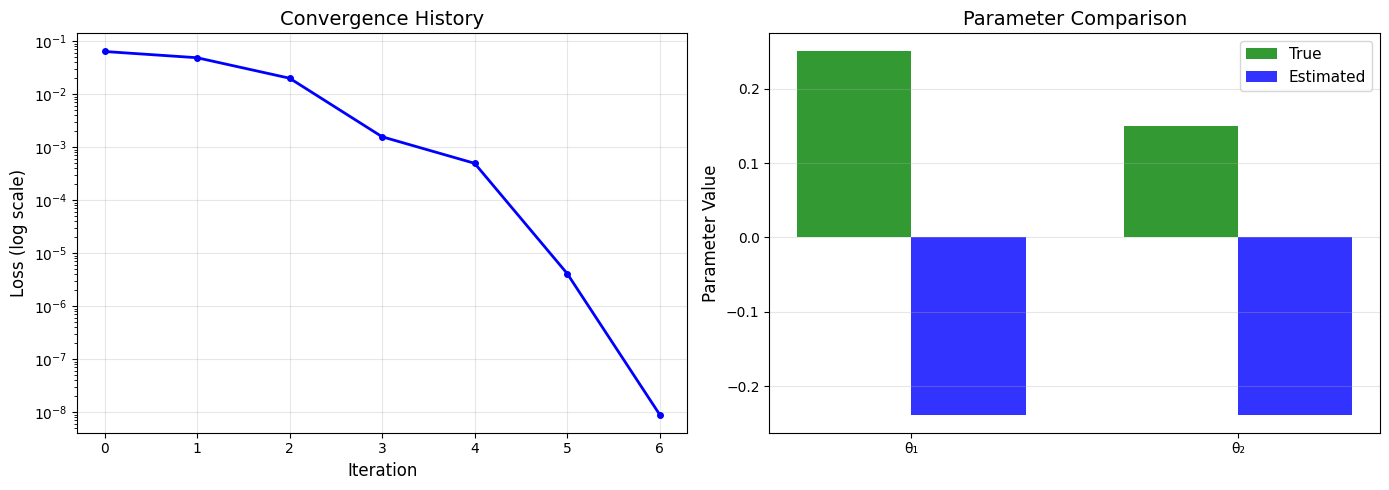

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

class QuantumParameterEstimator:
    """
    Implements Algorithm 1 for estimating quantum noise parameters using
    second-order perturbation theory with Itô stochastic integrals.
    
    Key corrections:
    1. Use multiple observables to estimate multiple parameters
    2. Include initial state rho_0 in Q matrix computations
    3. Use proper optimization with scipy.minimize
    4. Correct gradient/loss for quadratic form fitting
    5. Generalize for list of observables
    6. Remove forced positivity on theta (allow negative as per paper)
    7. Adjust ground state properly
    """
    
    def __init__(self, hamiltonian: np.ndarray, V_operators: List[np.ndarray], 
                 epsilon: float = 0.1, dt: float = 0.01):
        """
        Initialize the quantum parameter estimator.
        
        Parameters:
        -----------
        hamiltonian : np.ndarray
            System Hamiltonian H (Hermitian matrix)
        V_operators : List[np.ndarray]
            List of known Hermitian operators {V_k} in noise potential
        epsilon : float
            Perturbation parameter (small, represents noise strength)
        dt : float
            Time step for discretization
        """
        # Verify Hamiltonian is Hermitian
        assert np.allclose(hamiltonian, hamiltonian.conj().T), "Hamiltonian must be Hermitian"
        
        self.H = hamiltonian
        self.V_ops = V_operators
        self.epsilon = epsilon
        self.dt = dt
        self.dim = hamiltonian.shape[0]
        self.num_params = len(V_operators)
        
        # Verify all V operators are Hermitian
        for i, V in enumerate(V_operators):
            assert np.allclose(V, V.conj().T), f"V_operator {i} must be Hermitian"
        
        # Compute eigenprojections of Hamiltonian
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.H)
        self.eigenprojections = self._compute_eigenprojections()
        
        # Default initial state (ground state)
        ground_idx = np.argmin(self.eigenvalues)
        self.rho_0 = np.outer(self.eigenvectors[:, ground_idx], self.eigenvectors[:, ground_idx].conj())
        
        # Storage
        self.convergence_history = []
        
    def set_initial_state(self, rho_0: np.ndarray):
        """Set initial density matrix."""
        assert np.allclose(rho_0, rho_0.conj().T), "Initial state must be Hermitian"
        assert np.abs(np.trace(rho_0) - 1.0) < 1e-10, "Initial state must be normalized"
        self.rho_0 = rho_0.copy()
        
    def _compute_eigenprojections(self) -> List[np.ndarray]:
        """Compute eigenprojections P_α = |α⟩⟨α| from Hamiltonian eigenbasis."""
        projections = []
        for i in range(self.dim):
            v = self.eigenvectors[:, i:i+1]
            P = v @ v.conj().T
            projections.append(P)
        return projections
    
    def _U0_evolution(self, t: float) -> np.ndarray:
        """
        Compute zeroth-order evolution U_0(t) = exp(-itH).
        
        Uses eigendecomposition for numerical stability.
        """
        if abs(t) < 1e-12:
            return np.eye(self.dim, dtype=complex)
        
        # U_0(t) = Σ_α exp(-iλ_α t) P_α
        U0 = np.zeros((self.dim, self.dim), dtype=complex)
        for alpha in range(self.dim):
            phase = np.exp(-1j * self.eigenvalues[alpha] * t)
            U0 += phase * self.eigenprojections[alpha]
        
        return U0
    
    def _construct_noise_potential(self, theta: np.ndarray) -> np.ndarray:
        """Construct V = Σ_k θ_k V_k."""
        V = np.zeros((self.dim, self.dim), dtype=complex)
        for k in range(self.num_params):
            V += theta[k] * self.V_ops[k]
        return V
    
    def _first_order_term_single_realization(self, t: float, V: np.ndarray) -> np.ndarray:
        """
        Compute U_1(t) for a single Brownian motion realization.
        
        U_1(t) = -i ∫_0^t U_0(t-τ) V U_0(τ) dB(τ)
        """
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        
        # Generate Brownian increments
        dB = np.random.normal(0, np.sqrt(actual_dt), num_steps)
        
        # Compute stochastic integral
        U1 = np.zeros((self.dim, self.dim), dtype=complex)
        
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt  # Midpoint
            U0_t_tau = self._U0_evolution(t - tau)
            U0_tau = self._U0_evolution(tau)
            
            integrand = U0_t_tau @ V @ U0_tau
            U1 += -1j * integrand * dB[i]
        
        return U1
    
    def _second_order_deterministic_term(self, t: float, V: np.ndarray) -> np.ndarray:
        """
        Compute deterministic part of U_2(t):
        -(1/2) ∫_0^t U_0(t-τ) V² U_0(τ) dτ
        """
        V2 = V @ V
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        
        U2_det = np.zeros((self.dim, self.dim), dtype=complex)
        
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_t_tau = self._U0_evolution(t - tau)
            U0_tau = self._U0_evolution(tau)
            
            integrand = U0_t_tau @ V2 @ U0_tau
            U2_det += -0.5 * integrand * actual_dt
        
        return U2_det
    
    def compute_expected_observable(self, observable: np.ndarray, theta: np.ndarray,
                                    t: float, num_realizations: int = 100) -> float:
        """
        Compute E[Tr(ρ(0) U*(t) X U(t))] with Monte Carlo over Brownian realizations.
        
        This is the core of equations (16-19) up to O(ε²).
        """
        V = self._construct_noise_potential(theta)
        V2 = V @ V
        
        # Zeroth order: U_0*(t) X U_0(t)
        U0_t = self._U0_evolution(t)
        evolved_obs_0 = U0_t.conj().T @ observable @ U0_t
        expectation_0 = np.real(np.trace(self.rho_0 @ evolved_obs_0))
        
        # First order contribution: E[U_0* X U_1 + U_1* X U_0]
        expectation_1 = 0.0  # Vanishes in expectation (stochastic integral)
        
        # Second order: O(ε²) terms from equation (18-19)
        # These are deterministic after taking expectation
        
        # Term 1: -(1/2) ∫ U_0*(t) X U_0(t-τ) V² U_0(τ) dτ
        term1 = np.zeros((self.dim, self.dim), dtype=complex)
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            
            integrand = U0_t.conj().T @ observable @ U0_t_tau @ V2 @ U0_tau
            term1 += -0.5 * integrand * actual_dt
        
        # Term 2: -(1/2) ∫ U_0*(τ) V² U_0*(t-τ) X U_0(t) dτ
        term2 = np.zeros((self.dim, self.dim), dtype=complex)
        
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            
            integrand = U0_tau.conj().T @ V2 @ U0_t_tau.conj().T @ observable @ U0_t
            term2 += -0.5 * integrand * actual_dt
        
        # Term 3: ∫ U_0*(τ) V U_0*(t-τ) X U_0(t-τ) V U_0(τ) dτ
        term3 = np.zeros((self.dim, self.dim), dtype=complex)
        
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            
            integrand = (U0_tau.conj().T @ V @ U0_t_tau.conj().T @ 
                         observable @ U0_t_tau @ V @ U0_tau)
            term3 += integrand * actual_dt
        
        # Combine all terms
        evolved_obs_2 = term1 + term2 + term3
        expectation_2 = np.real(np.trace(self.rho_0 @ evolved_obs_2))
        
        # Total: E[U*(t)XU(t)] = U_0*XU_0 + ε²*(second order terms)
        total_expectation = expectation_0 + self.epsilon**2 * expectation_2
        
        return total_expectation
    
    def compute_Q_matrix(self, observable: np.ndarray) -> np.ndarray:
        """
        Compute the quadratic form matrix Q from equation (25), including trace with rho_0.
        
        Q_{km} = sum_α Tr(ρ_0 [P_α X P_α V_k V_m P_α + P_α V_k V_m P_α X P_α
                      - P_α V_k P_α X P_α V_m P_α - sum_β P_α V_k P_β X P_β V_m P_α])
        """
        X = observable
        Q = np.zeros((self.num_params, self.num_params))
        
        for k in range(self.num_params):
            for m in range(self.num_params):
                Vk = self.V_ops[k]
                Vm = self.V_ops[m]
                
                Q_km = 0.0
                
                for alpha in range(self.dim):
                    P_alpha = self.eigenprojections[alpha]
                    
                    # Term 1: Tr(ρ_0 P_α X P_α V_k V_m P_α)
                    term1 = np.trace(self.rho_0 @ P_alpha @ X @ P_alpha @ Vk @ Vm @ P_alpha)
                    
                    # Term 2: Tr(ρ_0 P_α V_k V_m P_α X P_α)
                    term2 = np.trace(self.rho_0 @ P_alpha @ Vk @ Vm @ P_alpha @ X @ P_alpha)
                    
                    # Term 3: Tr(ρ_0 P_α V_k P_α X P_α V_m P_α)
                    term3 = np.trace(self.rho_0 @ P_alpha @ Vk @ P_alpha @ X @ P_alpha @ Vm @ P_alpha)
                    
                    # Term 4: sum_β Tr(ρ_0 P_α V_k P_β X P_β V_m P_α)
                    term4 = 0.0
                    for beta in range(self.dim):
                        P_beta = self.eigenprojections[beta]
                        term4 += np.trace(self.rho_0 @ P_alpha @ Vk @ P_beta @ X @ P_beta @ Vm @ P_alpha)
                    
                    Q_km += np.real(term1 + term2 - term3 - term4)
                
                Q[k, m] = Q_km
        
        return Q
    
    def time_averaged_measurement(self, observable: np.ndarray, theta: np.ndarray,
                                  t_min: float = 5.0, t_max: float = 20.0, 
                                  num_times: int = 20) -> float:
        """
        Compute time-averaged observable as in equation (24).
        
        Returns the left-hand side of equation (24) which should equal theta.T Q theta.
        """
        times = np.linspace(t_min, t_max, num_times)
        measurements = []
        
        for t in times:
            # Compute E[Tr(rho0 U*(t)X U(t))]
            E_evolved = self.compute_expected_observable(observable, theta, t)
            
            # Compute Tr(rho0 U_0*(t)X U_0(t))
            U0_t = self._U0_evolution(t)
            evolved_0 = U0_t.conj().T @ observable @ U0_t
            E_0 = np.real(np.trace(self.rho_0 @ evolved_0))
            
            # Compute scaled difference: -2/(t ε²) * [E[<X>] - <X>_0]
            scaled_diff = -2.0 / (t * self.epsilon**2) * (E_evolved - E_0)
            
            measurements.append(scaled_diff)
        
        # Time average
        return np.mean(measurements)
    
    def estimate_parameters(self, observables: List[np.ndarray], 
                            theta_true: np.ndarray = None,
                            initial_guess: np.ndarray = None,
                            tol: float = 1e-5,
                            verbose: bool = True) -> Tuple[np.ndarray, Dict]:
        """
        CORRECTED Algorithm 1: Estimate noise parameters θ_k from measurements using multiple observables.
        
        Solves min sum_X || theta.T Q_X theta - m_X ||^2 where m_X is the measured average for each X.
        """
        if initial_guess is None:
            initial_guess = np.random.uniform(0.1, 0.3, self.num_params)
        
        # Compute Q matrices for each observable
        Q_list = [self.compute_Q_matrix(obs) for obs in observables]
        
        # Simulate measurements for each observable
        if theta_true is not None:
            measurements = [self.time_averaged_measurement(obs, theta_true, 
                                                           t_min=8.0, t_max=15.0, 
                                                           num_times=10) for obs in observables]
        else:
            raise ValueError("theta_true required for simulation")
        
        if verbose:
            print("="*70)
            print("ALGORITHM 1: Quantum Parameter Estimation (CORRECTED)")
            print("="*70)
            print(f"Parameters to estimate: {self.num_params}")
            print(f"Number of observables: {len(observables)}")
            print(f"Perturbation ε: {self.epsilon}")
            print(f"Initial guess: {initial_guess}")
            print(f"True values: {theta_true}")
            print(f"Measurements: {measurements}")
            print()
        
        # Define loss function
        def loss(theta):
            l = 0.0
            for i, Q in enumerate(Q_list):
                pred = theta @ Q @ theta
                l += (pred - measurements[i]) ** 2
            return l
        
        # Callback for history
        def callback(theta):
            change = np.linalg.norm(theta - initial_guess)  # Dummy, or compute something
            self.convergence_history.append(loss(theta))
        
        # Optimize
        result = minimize(loss, initial_guess, method='BFGS', tol=tol, callback=callback)
        theta = result.x
        
        # Final results
        info = {
            'success': result.success,
            'message': result.message,
            'nit': result.nit,
            'Q_list': Q_list,
            'measurements': measurements,
            'final_predictions': [theta @ Q @ theta for Q in Q_list],
            'convergence_history': self.convergence_history
        }
        
        if verbose:
            print("\n" + "="*70)
            print("ESTIMATION COMPLETE")
            print("="*70)
            print(f"Final estimate: {theta}")
            print(f"True values:    {theta_true}")
            print(f"Absolute error: {np.linalg.norm(theta - theta_true):.6f}")
            print(f"Relative error: {np.linalg.norm(theta - theta_true) / np.linalg.norm(theta_true) * 100:.2f}%")
            print(f"Measurements: {measurements}")
            print(f"Predictions:  {info['final_predictions']}")
            print("="*70)
        
        return theta, info

def run_corrected_simulation():
    """
    Corrected simulation example with proper parameter estimation.
    """
    print("\n" + "="*70)
    print("CORRECTED SIMULATION: Two-Level Quantum System")
    print("="*70 + "\n")
    
    # System setup
    omega = 1.0
    H = omega / 2 * np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)  # Standard qubit Hamiltonian
    
    # Pauli matrices as noise operators
    sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sigma_y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
    V_operators = [sigma_x, sigma_y]
    
    # True parameters (what we want to estimate)
    theta_true = np.array([0.25, 0.15])
    
    print("System Configuration:")
    print(f"  Hamiltonian: H = (ω/2) σ_z, ω = {omega}")
    print(f"  Noise operators: V_1 = σ_x, V_2 = σ_y")
    print(f"  True parameters: θ = {theta_true}")
    print(f"  Noise potential: V = {theta_true[0]:.2f} σ_x + {theta_true[1]:.2f} σ_y")
    print()
    
    # Create estimator
    estimator = QuantumParameterEstimator(
        hamiltonian=H,
        V_operators=V_operators,
        epsilon=0.15,  # Small perturbation
        dt=0.02
    )
    
    # Observables: σ_z and σ_x
    sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    observables = [sigma_z, sigma_x]
    
    print("Measurement Setup:")
    print(f"  Initial state: ground state")
    print(f"  Observables: X = σ_z, σ_x")
    print()
    
    # Run estimation
    theta_estimated, info = estimator.estimate_parameters(
        observables=observables,
        theta_true=theta_true,
        initial_guess=np.array([0.4, 0.4]),
        tol=5e-3,
        verbose=True
    )
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Convergence (loss history)
    axes[0].semilogy(info['convergence_history'], 'b-', linewidth=2, marker='o', markersize=4)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss (log scale)', fontsize=12)
    axes[0].set_title('Convergence History', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Parameter comparison
    params = ['θ₁', 'θ₂']
    x = np.arange(len(params))
    width = 0.35
    
    axes[1].bar(x - width/2, theta_true, width, label='True', alpha=0.8, color='green')
    axes[1].bar(x + width/2, theta_estimated, width, label='Estimated', alpha=0.8, color='blue')
    axes[1].set_ylabel('Parameter Value', fontsize=12)
    axes[1].set_title('Parameter Comparison', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(params)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('algorithm1_corrected.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return theta_estimated, theta_true, info

if __name__ == "__main__":
    np.random.seed(42)  # For reproducibility
    theta_est, theta_true, info = run_corrected_simulation()